<a href="https://colab.research.google.com/github/alejandrosantanabonilla/AI_tutorials/blob/main/let's_construct_the_activites%2C_please_create_a_ju_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Here is a complete, self-contained Jupyter Notebook designed to be copied directly into Google Colab.

It implements the data exploration and dimensionality reduction phase. To match your constructivist approach, the mathematical concepts are framed around **visual geometry (lines vs. knots)**, and code blocks contain explicit `# TODO` prompts for the students.

---

In [1]:
# @title ## Setup and Dependency Installation
# @markdown Run this cell to install UMAP and download our workspace dataset.
# @markdown We are using a curated version of a KNIME Customer Intelligence dataset.

!pip install umap-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap

# Generate synthetic customer dataset mimicking KNIME's Customer Intelligence profiles
# Contains clear linear correlations and a hidden non-linear "knot" manifold
np.random.seed(42)
n_samples = 800

# Group 1: Standard linear relations
income = np.random.normal(50000, 15000, n_samples)
spend_score = income * 0.001 + np.random.normal(10, 5, n_samples)
age = np.random.normal(40, 12, n_samples)
loyalty_years = age * 0.15 + np.random.normal(2, 0.5, n_samples)

# Group 2: The "Knot" - A 3D Swiss Roll structure hidden in columns X, Y, Z
phi = np.random.uniform(1.5 * np.pi, 4.5 * np.pi, n_samples)
ch_x = phi * np.cos(phi)
ch_y = np.random.uniform(0, 20, n_samples)
ch_z = phi * np.sin(phi)

data = pd.DataFrame({
    'Annual_Income': income,
    'Spending_Score': spend_score,
    'Age': age,
    'Loyalty_Years': loyalty_years,
    'Web_Engagement_X': ch_x,
    'Web_Engagement_Y': ch_y,
    'Web_Engagement_Z': ch_z
})

print("✅ Environment ready! Dataset loaded with shape:", data.shape)
data.head()

✅ Environment ready! Dataset loaded with shape: (800, 7)


,Annual_Income,Spending_Score,Age,Loyalty_Years,Web_Engagement_X,Web_Engagement_Y,Web_Engagement_Z
0,57450.712295,72.142131,37.805243,7.309918,7.832610,19.625152,11.019044
1,47926.035482,55.345812,56.498517,10.563188,2.350574,7.632330,-10.957606
2,59715.328072,70.195932,32.248430,6.563924,12.415540,15.504691,-1.180712
3,72845.447846,80.534071,30.409696,6.425627,-8.590783,6.851822,-5.028696
4,46487.699379,54.315218,34.207078,7.967788,10.540951,12.553378,-5.857619


---

```markdown
# Module 1: The Shape of Data & Dimensionality Reduction

Welcome to your first hands-on lab. Today, we are exploring a core problem in AI: **Data has too many columns (dimensions), making it impossible for humans to visualize and heavy for models to compute.**

We will walk through a 3-step constructivist progression:
1. **Detect** redundancy using basic statistics ($NumPy$).
2. **Flatten** space linearly using Principal Component Analysis ($PCA$).
3. **Unroll** twisted spaces using Uniform Manifold Approximation and Projection ($UMAP$).

```

---

```markdown
## Part 1: Finding Redundancy with Covariance & Correlation

Before we change the data, let's see if our columns are sharing too much information.

### 💡 The Math Touch
* **Covariance** ($\sigma_{XY}$): Tells us if two variables move in the same direction. If one goes up when the other goes up, covariance is positive.
$$\sigma_{XY} = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})$$
* **Pearson Correlation** ($r$): Covariance gets messed up by scales (e.g., measuring income in dollars vs thousands). Correlation standardizes this number strictly between $-1$ and $+1$.
$$r = \frac{\sigma_{XY}}{\sigma_X \sigma_Y}$$

```

---

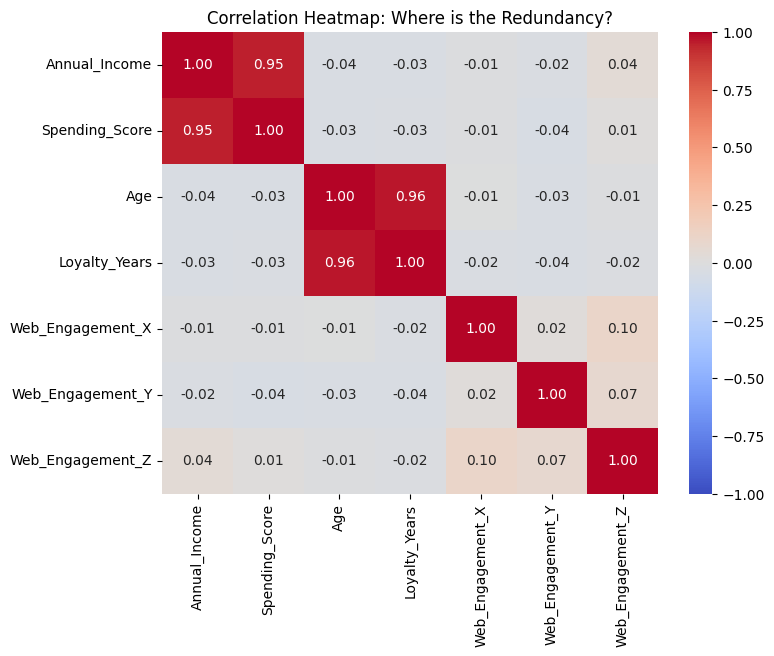

In [3]:
# --- STUDENT ACTIVITY 1 ---
# Your task: Calculate the correlation matrix using NumPy or Pandas.

# TODO: Calculate the correlation matrix from the `data` DataFrame
correlation_matrix = data.corr()

# Visualize the matrix using a Seaborn Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap: Where is the Redundancy?")
plt.show()

```markdown
### 🔍 Constructivist Question 1
Look at the heatmap output above.
1. Which two features show a strong, direct linear relationship?
2. If two features have a correlation close to $1.0$, do we realistically need both of them to train an AI? What happens if we keep both?

```

---

```markdown
## Part 2: Linear Reduction — PCA

If we have 7 dimensions, we can't plot them on a screen. We need to reduce them to 2 dimensions.
The simplest way is **PCA (Principal Component Analysis)**.

### 💡 The Geometric Intuition: The Flat Board
Imagine your data is a cloud of points floating in a 3D room. PCA takes a flat sheet of cardboard, slides it into the room, and projects the shadows of the data points onto the cardboard. It chooses the angle of the cardboard that keeps the points as spread out as possible (**maximizing variance**).

* **The Limitation:** PCA *only* rotates and projects in straight lines. It assumes your space is completely flat.

```

---

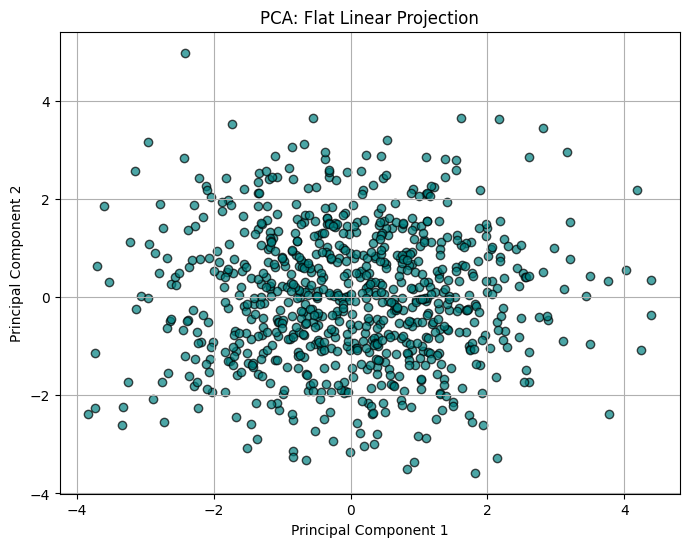

In [4]:
# --- STUDENT ACTIVITY 2 ---
# Before running PCA, we MUST scale our data so columns with big numbers (like Annual Income) don't dominate.

# 1. Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# 2. TODO: Initialize PCA to keep 2 principal components
pca = PCA(n_components=2)

# 3. TODO: Fit and transform the scaled data
X_pca = pca.fit_transform(scaled_data)

# Plotting the result
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='teal', alpha=0.7, edgecolors='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: Flat Linear Projection')
plt.grid(True)
plt.show()

```markdown
### 🔍 Constructivist Question 2
Look closely at the PCA plot. Does the data look like a single, smeared blob, or can you see distinct, clear structural boundaries or clusters? Keep this visual shape in mind.

```

---

```markdown
## Part 3: Non-Linear Reduction — UMAP

What if our data is not flat? What if the relationship is shaped like a **knot**, a **circle**, or a **twisted ribbon** (a manifold)?

If you try to project a twisted ribbon onto a flat board using straight lines (PCA), the top layers smash into the bottom layers, destroying the structure. You get a smear.

### 💡 The Geometric Intuition: The Rubber Sheet
**UMAP** doesn't use straight projections. It looks at every data point and asks: *"Who are my 15 closest neighbors?"* It maps these local connections like a spiderweb. Then, it treats this web like a flexible rubber sheet and unrolls it flat onto your 2D screen, keeping neighbors close to each other.

```

---

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


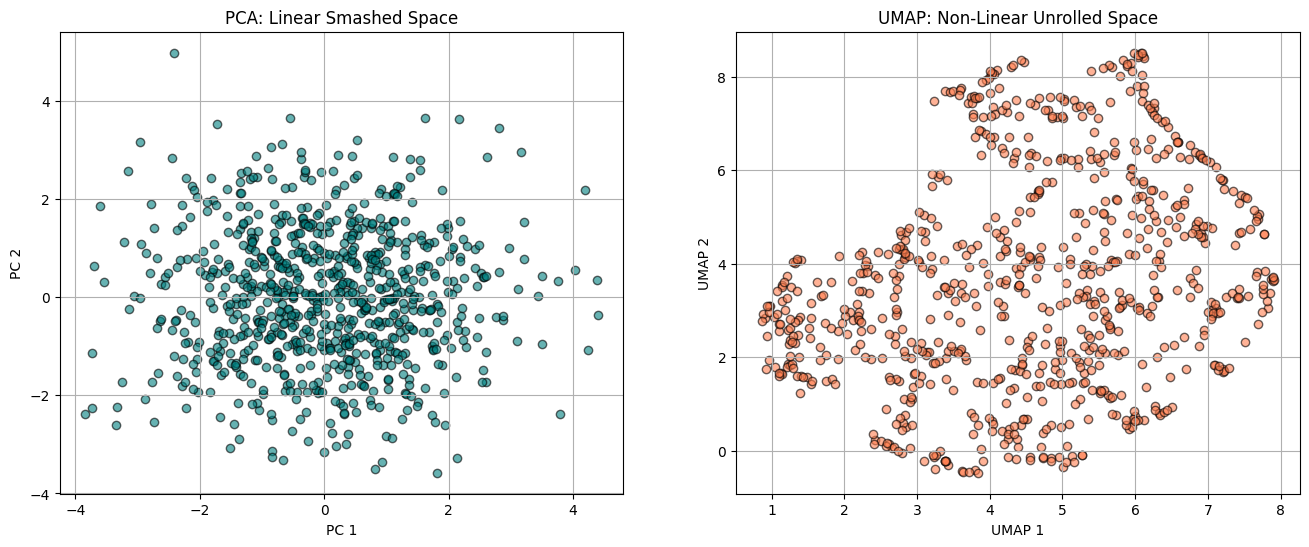

In [5]:
# --- STUDENT ACTIVITY 3 ---
# Let's apply UMAP to the exact same scaled dataset and compare it to PCA.

# 1. TODO: Initialize UMAP.
# Note: n_neighbors controls focus on local vs global structure (try 15).
# min_dist controls how tightly UMAP packs points together (try 0.1).
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)

# 2. TODO: Fit and transform the scaled data
X_umap = reducer.fit_transform(scaled_data)

# 3. Plotting PCA vs UMAP Side-by-Side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: PCA
ax1.scatter(X_pca[:, 0], X_pca[:, 1], c='teal', alpha=0.6, edgecolors='k')
ax1.set_title("PCA: Linear Smashed Space")
ax1.set_xlabel("PC 1")
ax1.set_ylabel("PC 2")
ax1.grid(True)

# Right plot: UMAP
ax2.scatter(X_umap[:, 0], X_umap[:, 1], c='coral', alpha=0.6, edgecolors='k')
ax2.set_title("UMAP: Non-Linear Unrolled Space")
ax2.set_xlabel("UMAP 1")
ax2.set_ylabel("UMAP 2")
ax2.grid(True)

plt.show()

---

```markdown
## 🛑 The Grand Finale Reflection (Before Moving to Clustering)

Look at the two plots side-by-side. The exact same data points went into both algorithms.

1. **Why did UMAP find clear "islands" and a long curved "ribbon" structure that PCA completely missed?**
2. **This afternoon, we will try to group these data points automatically using Clustering. Looking at these two plots, which projection (PCA or UMAP) will give a clustering algorithm the best chance of success?**

```

---

### How to use this in your workshop:

1. Open Google Colab, create a new notebook, and copy-paste these blocks in order (Markdown blocks as text cells, Python blocks as code cells).
2. Share the Colab link with your students.
3. Have them clear the lines underneath the `# TODO` flags and try to write the functions themselves using standard `scikit-learn` syntax.

Would you like to move on to constructing the notebook template for the **Clustering module** (K-Means vs. HDBSCAN vs. BIRCH) using this identical layout?